# Notebook 1: Datarening & Explorativ Dataanalys (EDA)

## Frågeställning



Kan vi förutsäga om en patient har hjärtsjukdom baserat på kliniska mätvärden?

(Potentiellt användningsområde: Läkare matar in en ny patients mätvärden och modellen svarar — sjuk eller frisk?)

## Dataset

**Källa:**  Kaggle
**Länk:**  https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
**Rader:**  918
**Variabler:**  12 totalt (11 input variabler + 1 målvariabel)
**Målvariabel:**  Hjärtsjukdom

## 1.1 Ladda in data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Läser in rådata från CSV-filen
df = pd.read_csv('Data/raw_heart_disease.csv')

# Visar de första 5 raderna för att bekräfta att datan laddades in korrekt
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
# Döper om kolumnerna till svenska för tydligare visualiseringar och presentation
df = df.rename(columns={
    'Age':            'Ålder',
    'Sex':            'Kön',
    'ChestPainType':  'Bröstsmärta',
    'RestingBP':      'Viloblodtryck',
    'Cholesterol':    'Kolesterol',
    'FastingBS':      'FastandeBlodsocker',
    'RestingECG':     'ViloEKG',
    'MaxHR':          'MaxHjärtfrekvens',
    'ExerciseAngina': 'Ansträngningssmärta',
    'Oldpeak':        'EKG_Sänkning',
    'ST_Slope':       'EKG_Lutning',
    'HeartDisease':   'Hjärtsjukdom'
})

## 1.2 Första översikt

In [3]:
# Hur många rader och kolumner har datasetet?
print(df.shape)

(918, 12)


In [4]:
# Vilka datatyper har kolumnerna?
# object = text, int64/float64 = siffror
print(df.dtypes)

Ålder                    int64
Kön                        str
Bröstsmärta                str
Viloblodtryck            int64
Kolesterol               int64
FastandeBlodsocker       int64
ViloEKG                    str
MaxHjärtfrekvens         int64
Ansträngningssmärta        str
EKG_Sänkning           float64
EKG_Lutning                str
Hjärtsjukdom             int64
dtype: object


In [5]:
# Finns det saknade värden?
saknade = df.isnull().sum()
if saknade.sum() == 0:
    print("Inga saknade värden hittades.")
else:
    print(saknade[saknade > 0])

Inga saknade värden hittades.


## 1.3 Hantera outliers

In [6]:
# Kollar hur många rader som har Kolesterol = 0
# Kolesterol kan aldrig vara 0 hos en levande person — dessa är förmodligen saknade värden
print(f"Antal rader med Kolesterol = 0:     {(df['Kolesterol'] == 0).sum()}")
print(f"Antal rader med Viloblodtryck = 0:  {(df['Viloblodtryck'] == 0).sum()}")

Antal rader med Kolesterol = 0:     172
Antal rader med Viloblodtryck = 0:  1


In [7]:
# Ersätter 0-värdena med medianen av giltiga värden (> 0)
# Vi använder medianen istället för medelvärdet eftersom den är mer robust mot extremvärden
for kol in ['Kolesterol', 'Viloblodtryck']:
    median = df[df[kol] > 0][kol].median()
    df[kol] = df[kol].replace(0, median)
    print(f"{kol}: 0-värden ersatta med median {median:.1f}")

Kolesterol: 0-värden ersatta med median 237.0
Viloblodtryck: 0-värden ersatta med median 130.0


In [8]:
# Verifierar att 0-värdena är borta
print(f"Kolesterol = 0 kvar:    {(df['Kolesterol'] == 0).sum()}")
print(f"Viloblodtryck = 0 kvar: {(df['Viloblodtryck'] == 0).sum()}")

Kolesterol = 0 kvar:    0
Viloblodtryck = 0 kvar: 0


## 1.4 Koda om kategoriska variabler

Maskininlärningsmodeller kan bara räkna med siffror — de förstår inte text. Vi omvandlar därför kategoriska kolumner till 0/1-kolumner

In [9]:
# Visar vilka kolumner som inte är numeriska — dessa behöver kodas om
print(df.select_dtypes(exclude='number').columns.tolist())

['Kön', 'Bröstsmärta', 'ViloEKG', 'Ansträngningssmärta', 'EKG_Lutning']


In [10]:
# Ersätter förkortningar och engelska värden med beskrivande svenska namn
# innan get_dummies — så att kolumnnamnen blir läsbara direkt
df['Bröstsmärta'] = df['Bröstsmärta'].replace({
    'ASY': 'IngenBröstsmärta',
    'TA':  'KlassiskHjärtsmärta',
    'ATA': 'OtypiskHjärtsmärta',
    'NAP': 'AnnanBröstsmärta'
})
df['ViloEKG'] = df['ViloEKG'].replace({
    'ST': 'Avvikelse'
})
df['Ansträngningssmärta'] = df['Ansträngningssmärta'].replace({
    'Y': 'Ja',
    'N': 'Nej'
})
df['EKG_Lutning'] = df['EKG_Lutning'].replace({
    'Up':   'Uppåt',
    'Down': 'Nedåt'
})

In [11]:
# Skapar en ny 0/1-kolumn per kategori
# Exempel: Kön (M/F) blir två kolumner — Kön_M och Kön_F
df = pd.get_dummies(df, columns=['Kön', 'Bröstsmärta', 'ViloEKG', 'Ansträngningssmärta', 'EKG_Lutning'], dtype=int)

print(f"Antal kolumner efter kodning: {df.shape[1]}")
df.head()

Antal kolumner efter kodning: 21


,Ålder,Viloblodtryck,Kolesterol,FastandeBlodsocker,MaxHjärtfrekvens,EKG_Sänkning,Hjärtsjukdom,Kön_F,Kön_M,Bröstsmärta_AnnanBröstsmärta,...,Bröstsmärta_KlassiskHjärtsmärta,Bröstsmärta_OtypiskHjärtsmärta,ViloEKG_Avvikelse,ViloEKG_LVH,ViloEKG_Normal,Ansträngningssmärta_Ja,Ansträngningssmärta_Nej,EKG_Lutning_Flat,EKG_Lutning_Nedåt,EKG_Lutning_Uppåt
0,40,140,289,0,172,0.0,0,0,1,0,...,0,1,0,0,1,0,1,0,0,1
1,49,160,180,0,156,1.0,1,1,0,1,...,0,0,0,0,1,0,1,1,0,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,1,0,0,...,0,0,0,0,1,1,0,1,0,0
4,54,150,195,0,122,0.0,0,0,1,1,...,0,0,0,0,1,0,1,0,0,1


Resultat av konvertering: 5 kategoriska variabler togs bort, och ersattes av 14 numeriska. Därför fick vi 9 fler kolumner än dem 12 vi hade från början, dvs 21

## 1.5 EDA & visualiseringar

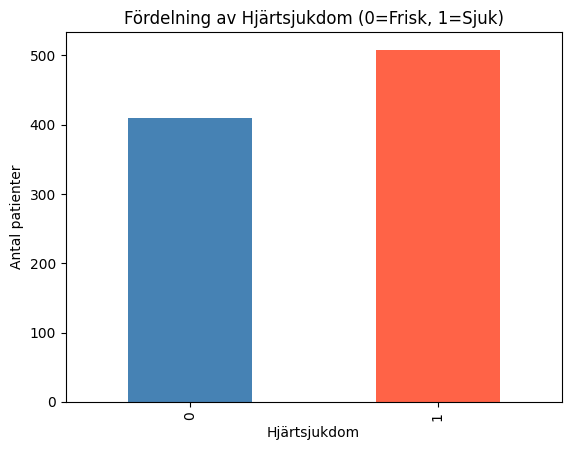

In [12]:
numeriska = ['Ålder', 'Viloblodtryck', 'Kolesterol', 'MaxHjärtfrekvens', 'EKG_Sänkning']

# Räknar antal patienter per klass (0=Frisk, 1=Sjuk)
# sort_index() säkerställer att 0 visas till vänster och 1 till höger
df['Hjärtsjukdom'].value_counts().sort_index().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Fördelning av Hjärtsjukdom (0=Frisk, 1=Sjuk)')
plt.ylabel('Antal patienter')
plt.show()

plt.rcParams['figure.dpi'] = 150  # Gör figurerna skarpare

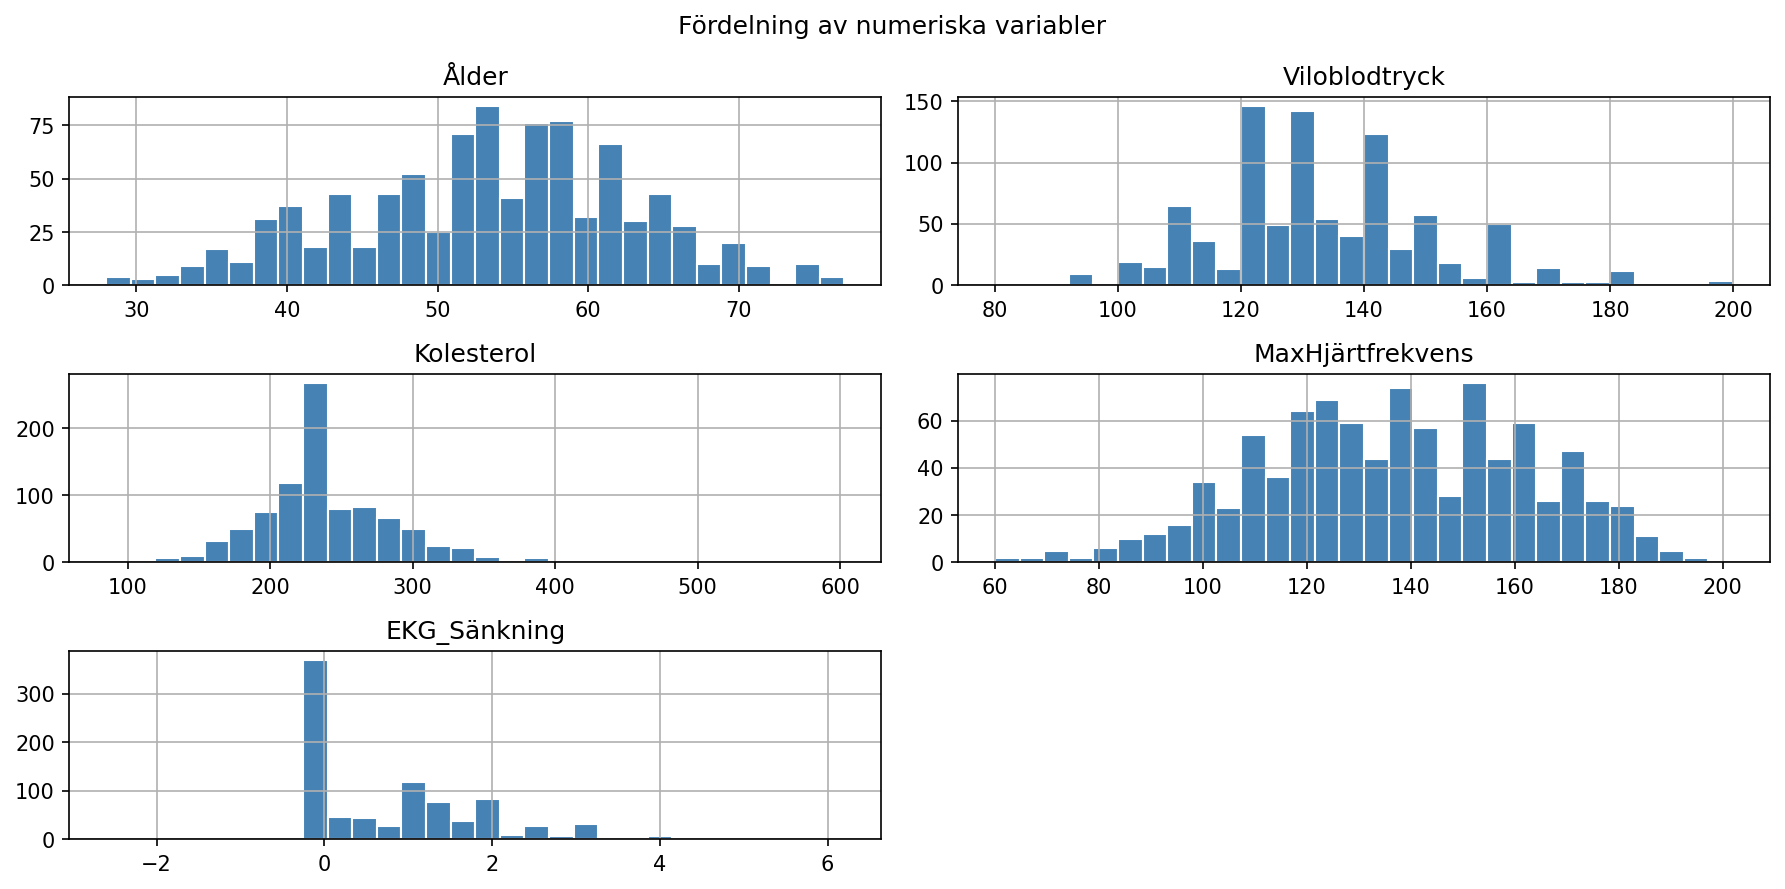

In [13]:
# Histogram för varje numerisk variabel — visar hur värdena fördelar sig
df[numeriska].hist(bins=30, figsize=(12, 6), color='steelblue', edgecolor='white')
plt.suptitle('Fördelning av numeriska variabler')
plt.tight_layout()
plt.show()

plt.rcParams['figure.dpi'] = 300  # Gör figurerna skarpare

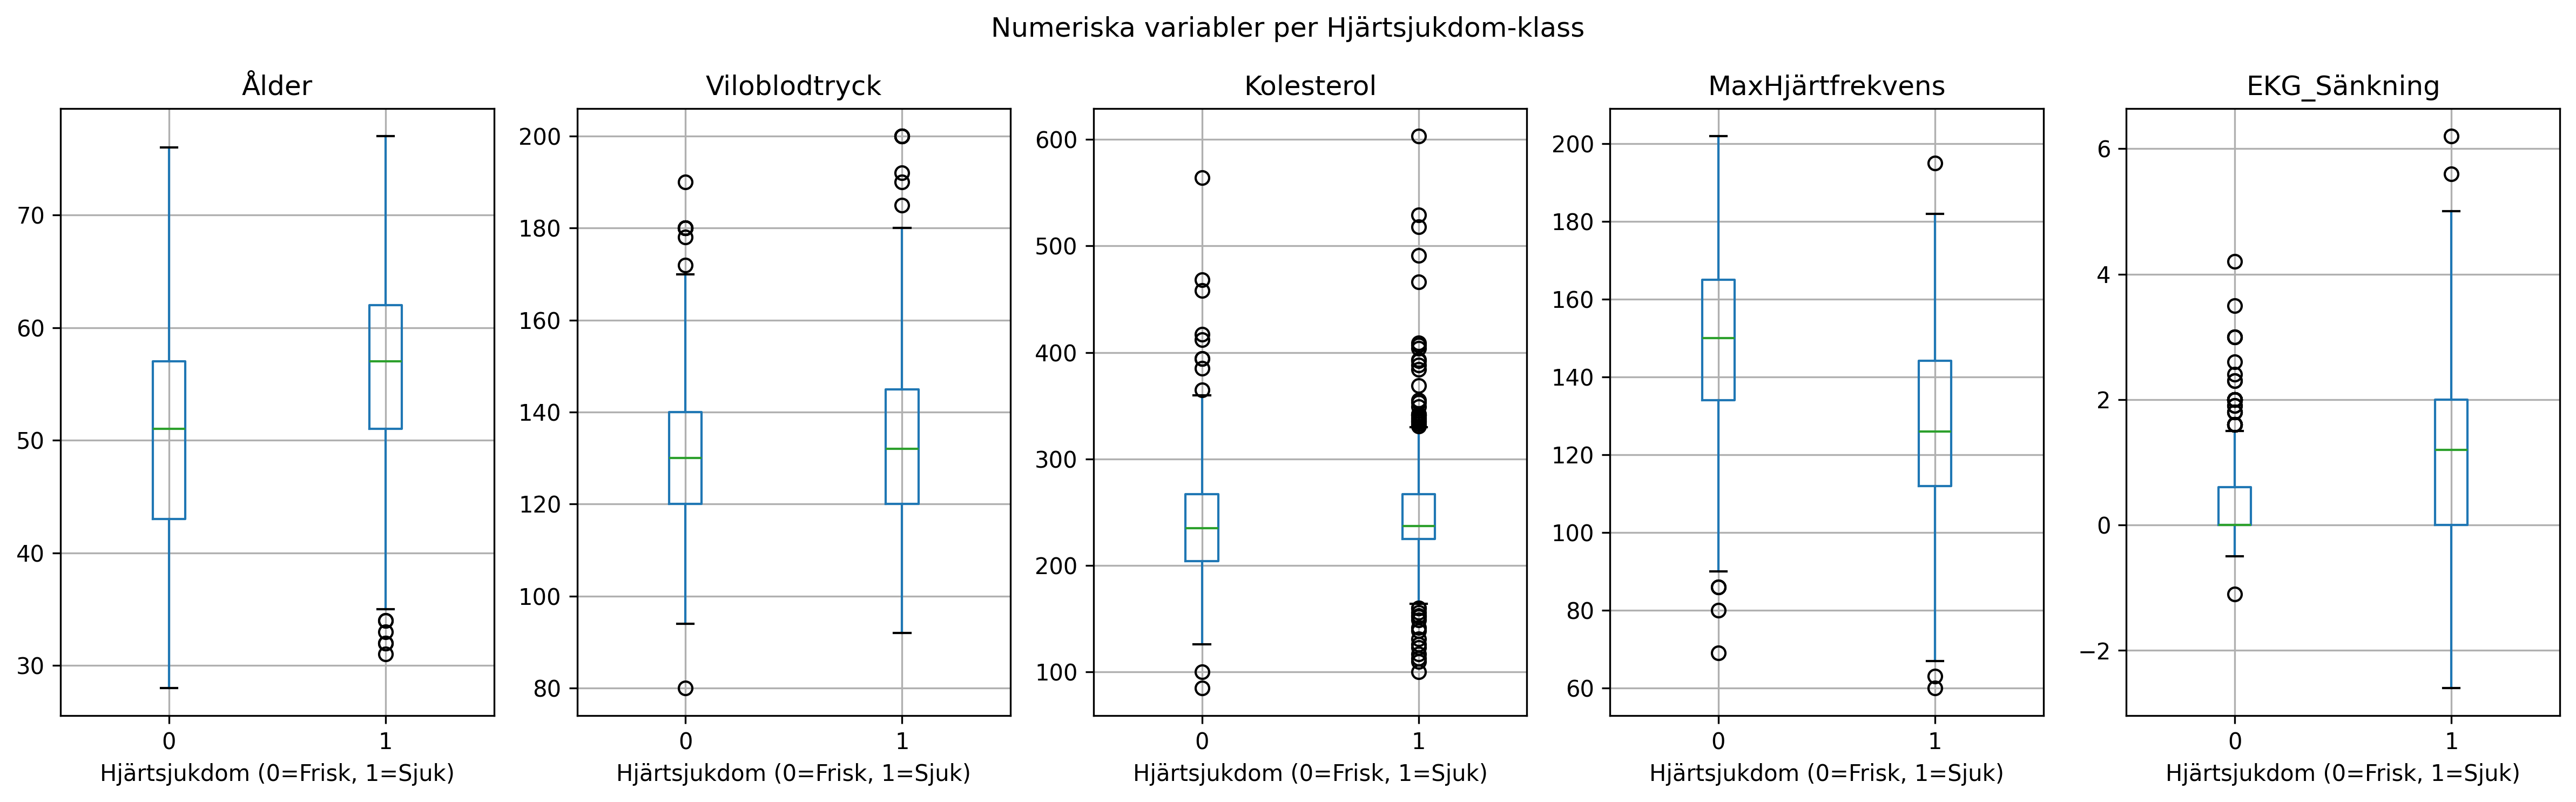

In [14]:
# Boxplot per variabel uppdelad på Hjärtsjukdom
# Visar vilka variabler som tydligast skiljer sjuka från friska
fig, axes = plt.subplots(1, len(numeriska), figsize=(16, 5))

for ax, kol in zip(axes, numeriska):
    df.boxplot(column=kol, by='Hjärtsjukdom', ax=ax)
    ax.set_xlabel('Hjärtsjukdom (0=Frisk, 1=Sjuk)')
    ax.set_title(kol)

plt.suptitle('')
fig.suptitle('Numeriska variabler per Hjärtsjukdom-klass')
plt.tight_layout()
plt.show()

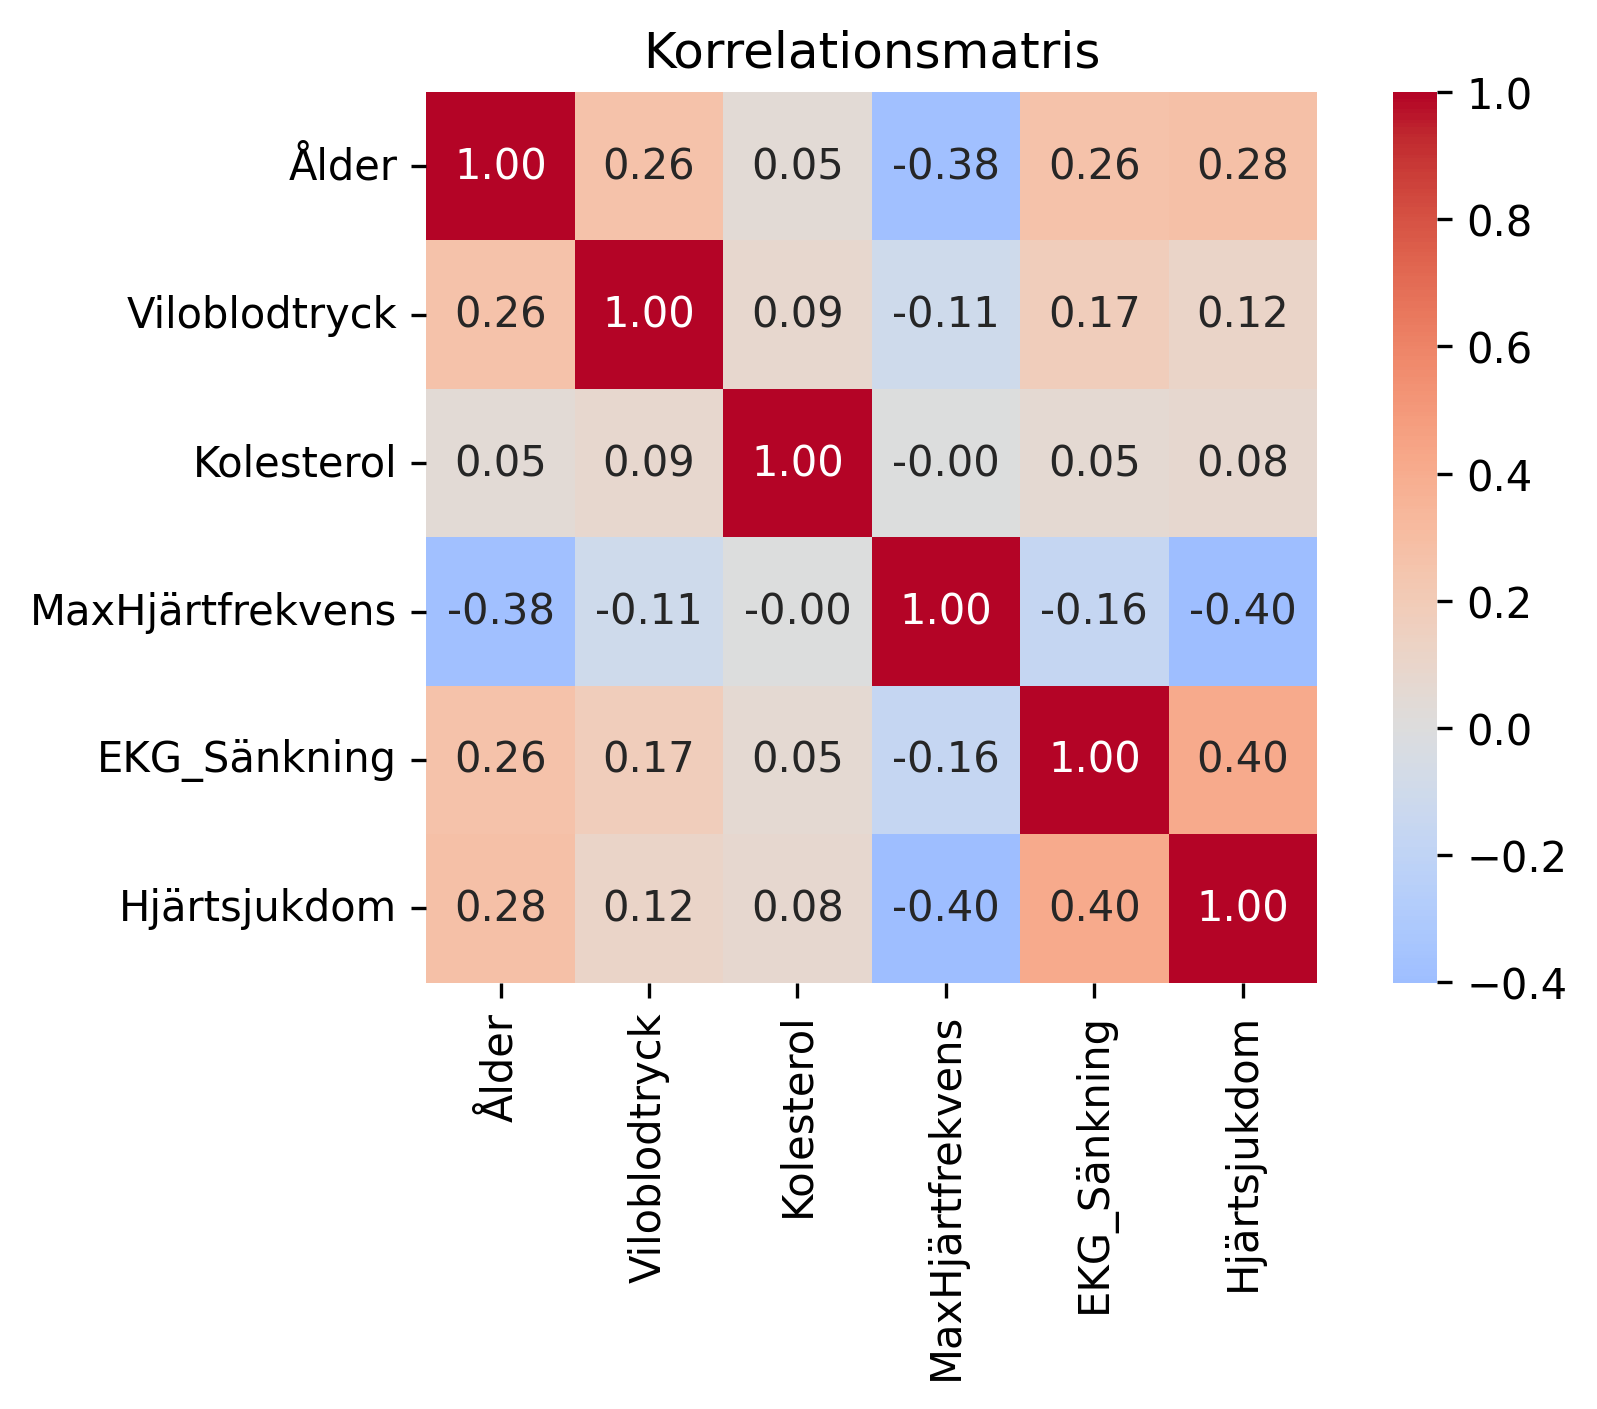

In [15]:
# Korrelationsheatmap — visar sambandet mellan numeriska variabler och målvariabeln
# Värden nära 1 eller -1 = starkt samband, nära 0 = svagt samband
korr = df[numeriska + ['Hjärtsjukdom']].corr()
sns.heatmap(korr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Korrelationsmatris')
plt.tight_layout()
plt.show()

## 1.6 Spara rent dataset

In [16]:
# Sparar det rensade och kodade datasetet så notebook 2 kan läsa in det
df.to_csv('Data/clean_heart_disease.csv', index=False)
print(f"Sparat: Data/clean_heart_disease.csv  ({df.shape[0]} rader, {df.shape[1]} kolumner)")

Sparat: Data/clean_heart_disease.csv  (918 rader, 21 kolumner)
